In [1]:
import numpy as np
import pandas as pd

from plotly.subplots import make_subplots

from pychemelt import Monomer
from pychemelt.utils.plotting import *

import plotly.graph_objs as go

import sys
sys.path.append('../')
from scripts import display_figure_static, set_condition_indexes_to_false

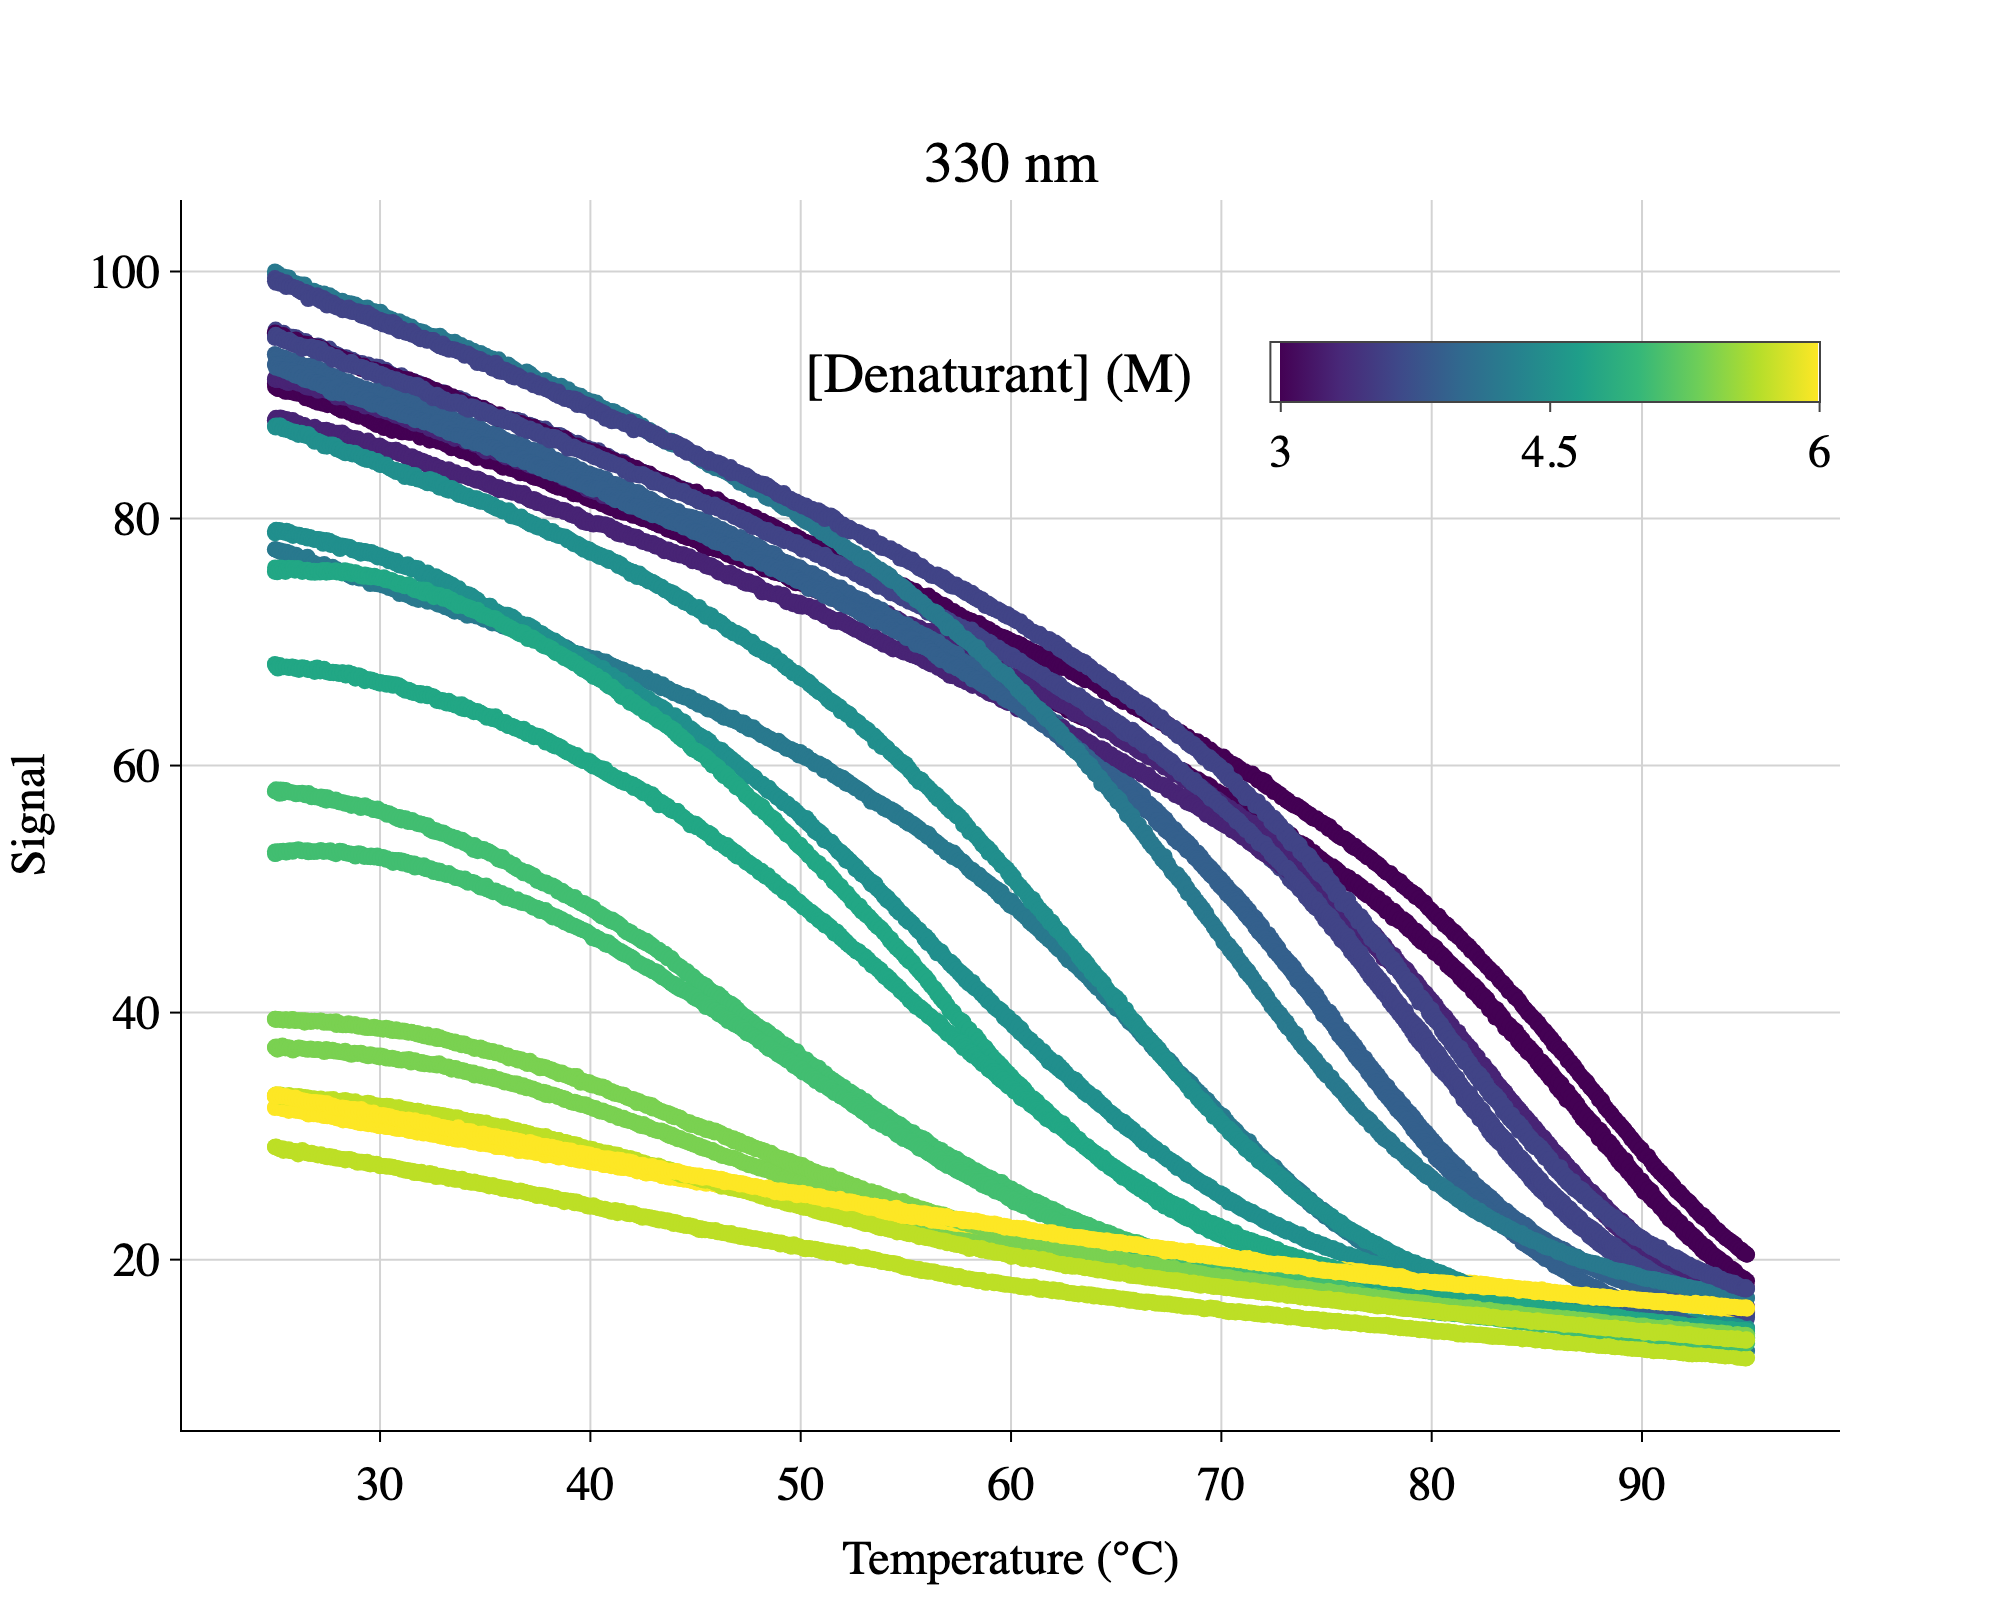

In [2]:
INDEX = 7
NAME = "G4A" # Name used in the manuscript

# creating a Sample object for the storage and processing of the DSF data
sample = Monomer()

# reading the data
sample.read_file(f'../../data/retiter1_GB1_GH1.xlsx')

sample.set_denaturant_concentrations()

# Selecting conditions
sample.set_signal(['330 nm'])#, '350 nm'])

conditions = [True]*48
# Index of the curves to be excluded from the analysis, starting from 1
outliers_or_other_data = ["1-22"] 

conditions = set_condition_indexes_to_false(conditions,outliers_or_other_data)

#using all curves except the curve without denaturant as in the paper
sample.select_conditions(conditions,normalise_to_global_max=True)

plot_config = PlotConfig()
plot_config.font_size = 24

legend_config = LegendConfig()
legend_config.color_bar_orientation = "h"
legend_config.color_bar_length = 0.6
legend_config.color_bar_x_pos = 0.7
legend_config.color_bar_y_pos = 0.9

#Plotting the selected signals against the temperature
fig = plot_unfolding(sample,plot_config=plot_config,legend_config=legend_config)
display_figure_static(fig,height=800, width=1000)

In [3]:
# Reducing the amount of data and preprocessing steps for a faster analysis
sample.pre_fit = False
sample.max_points = 200

sample.expand_multiple_signal()

sample.estimate_baseline_parameters(
    native_baseline_type='linear',
    unfolded_baseline_type='exponential',
)

# estimations of parameters
sample.estimate_derivative()
sample.guess_Tm()

# All local fit for parameter estimation
sample.fit_thermal_unfolding_local()

# Setting the number of residues of the protein for an initial estiamte of the Cp value
# We use a lower value than expected because of the hyperstability.
sample.n_residues = 60 
sample.guess_Cp()

sample.set_signal_id()

sample.compare_models(
    native_baseline_types=['linear','quadratic','exponential'],
    unfolded_baseline_types=['linear','quadratic','exponential'],
    global_model_types=['global_global_global'],
    neff=None
)

# Replace sample with the best model
best_model = sample.fit_objects[0]

/Users/oburastero/myenv/lib/python3.12/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/Users/oburastero/myenv/lib/python3.12/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))


In [4]:
print(sample.comparison_df)
# add sample name to the comparison dataframe - first column
sample.comparison_df.insert(0, 'Sample', NAME)
# Export to csv - use sample name as filename
sample.comparison_df.to_csv(f'./comparison_tables/{INDEX}_{NAME}_comparison.csv', index=False)

#sample.params_df[:4]

  Native Baseline Unfolded Baseline                           Model Type  \
0       quadratic       exponential  Global slopes and global intercepts   
1       quadratic            linear  Global slopes and global intercepts   
2          linear            linear  Global slopes and global intercepts   
3     exponential            linear  Global slopes and global intercepts   
4     exponential         quadratic  Global slopes and global intercepts   
5          linear       exponential  Global slopes and global intercepts   
6     exponential       exponential  Global slopes and global intercepts   
7       quadratic         quadratic  Global slopes and global intercepts   
8          linear         quadratic  Global slopes and global intercepts   

      Tm   ΔHm   ΔCp  m-value      AIC      BIC     EBIC  Reduced χ²  
0  127.2  97.7  0.88     2.42 -1149.21  -948.69  -589.23      0.6443  
1  126.5  96.6  0.86     2.40 -1111.81  -917.18  -566.44      0.6535  
2  121.6  94.2  0.91     2

In [5]:
# Estimate error using leave_one_out cross validation
best_model.leave_one_out_cross_validation()

# Save the leave one out results to a csv file
best_model.loo_df.to_csv(f'./leave_one_out_results/{INDEX}_{NAME}_loo.csv', index=False)

/Users/oburastero/myenv/lib/python3.12/site-packages/lmfit/minimizer.py:827: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(self.result.covar[jvar, jvar])))
/Users/oburastero/myenv/lib/python3.12/site-packages/lmfit/minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = float(np.sqrt(self.result.covar[ivar, ivar]))


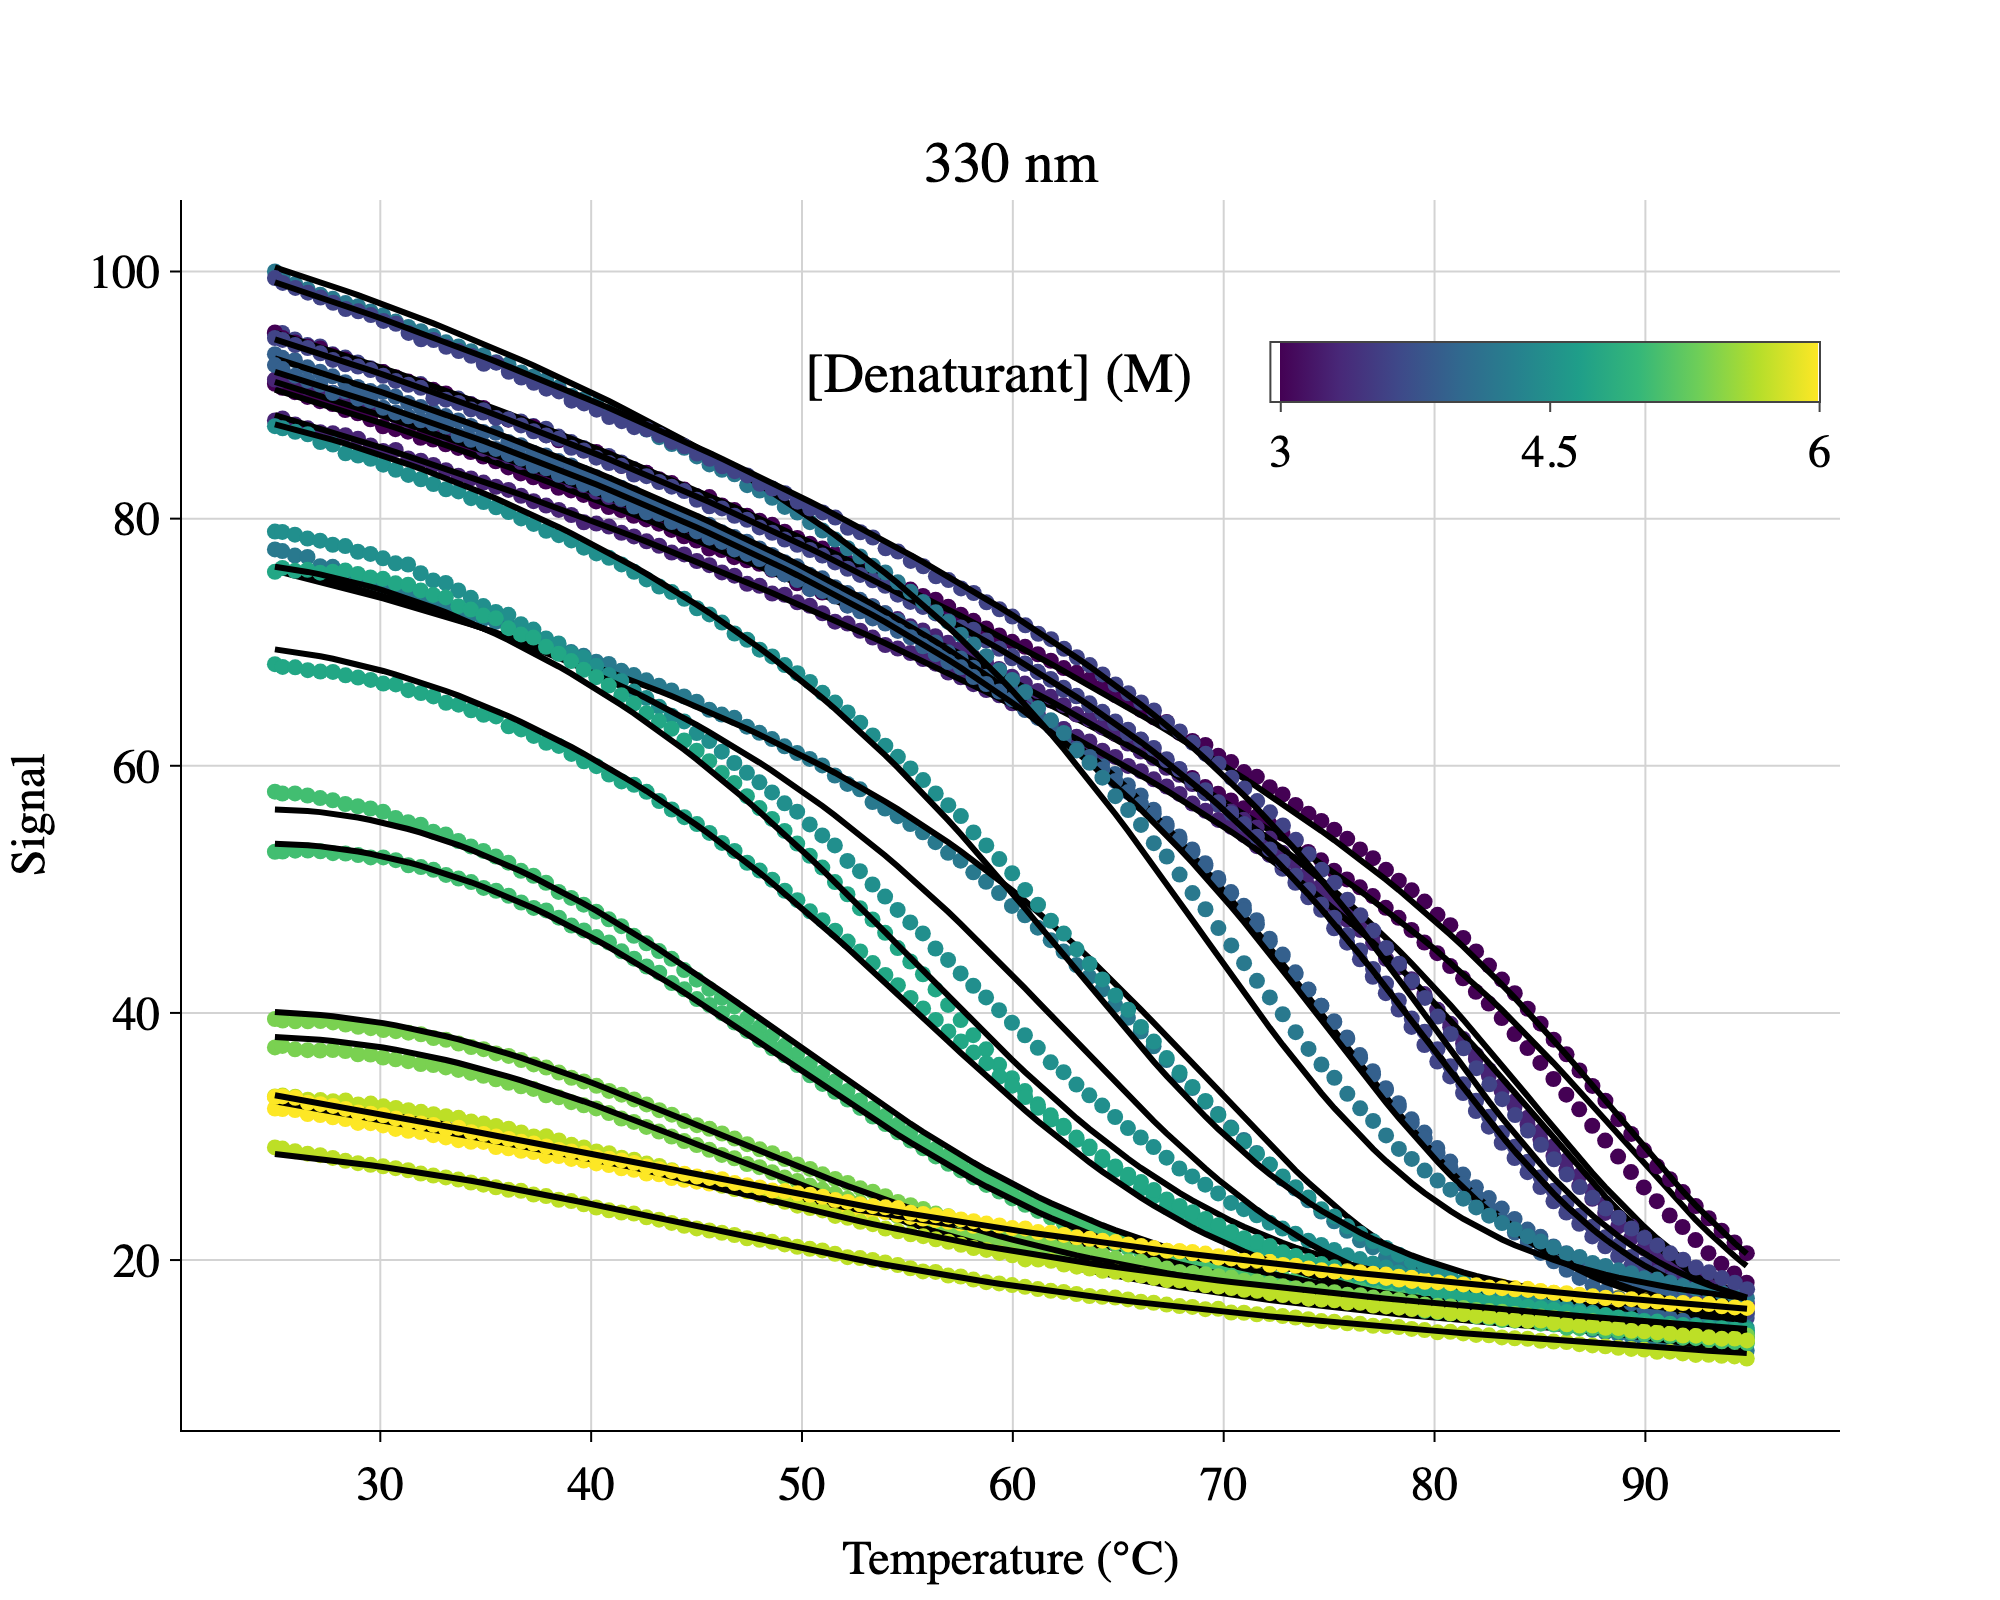

In [6]:
fig = plot_unfolding(best_model,plot_config=plot_config,legend_config=legend_config)
display_figure_static(fig,height=800, width=1000)

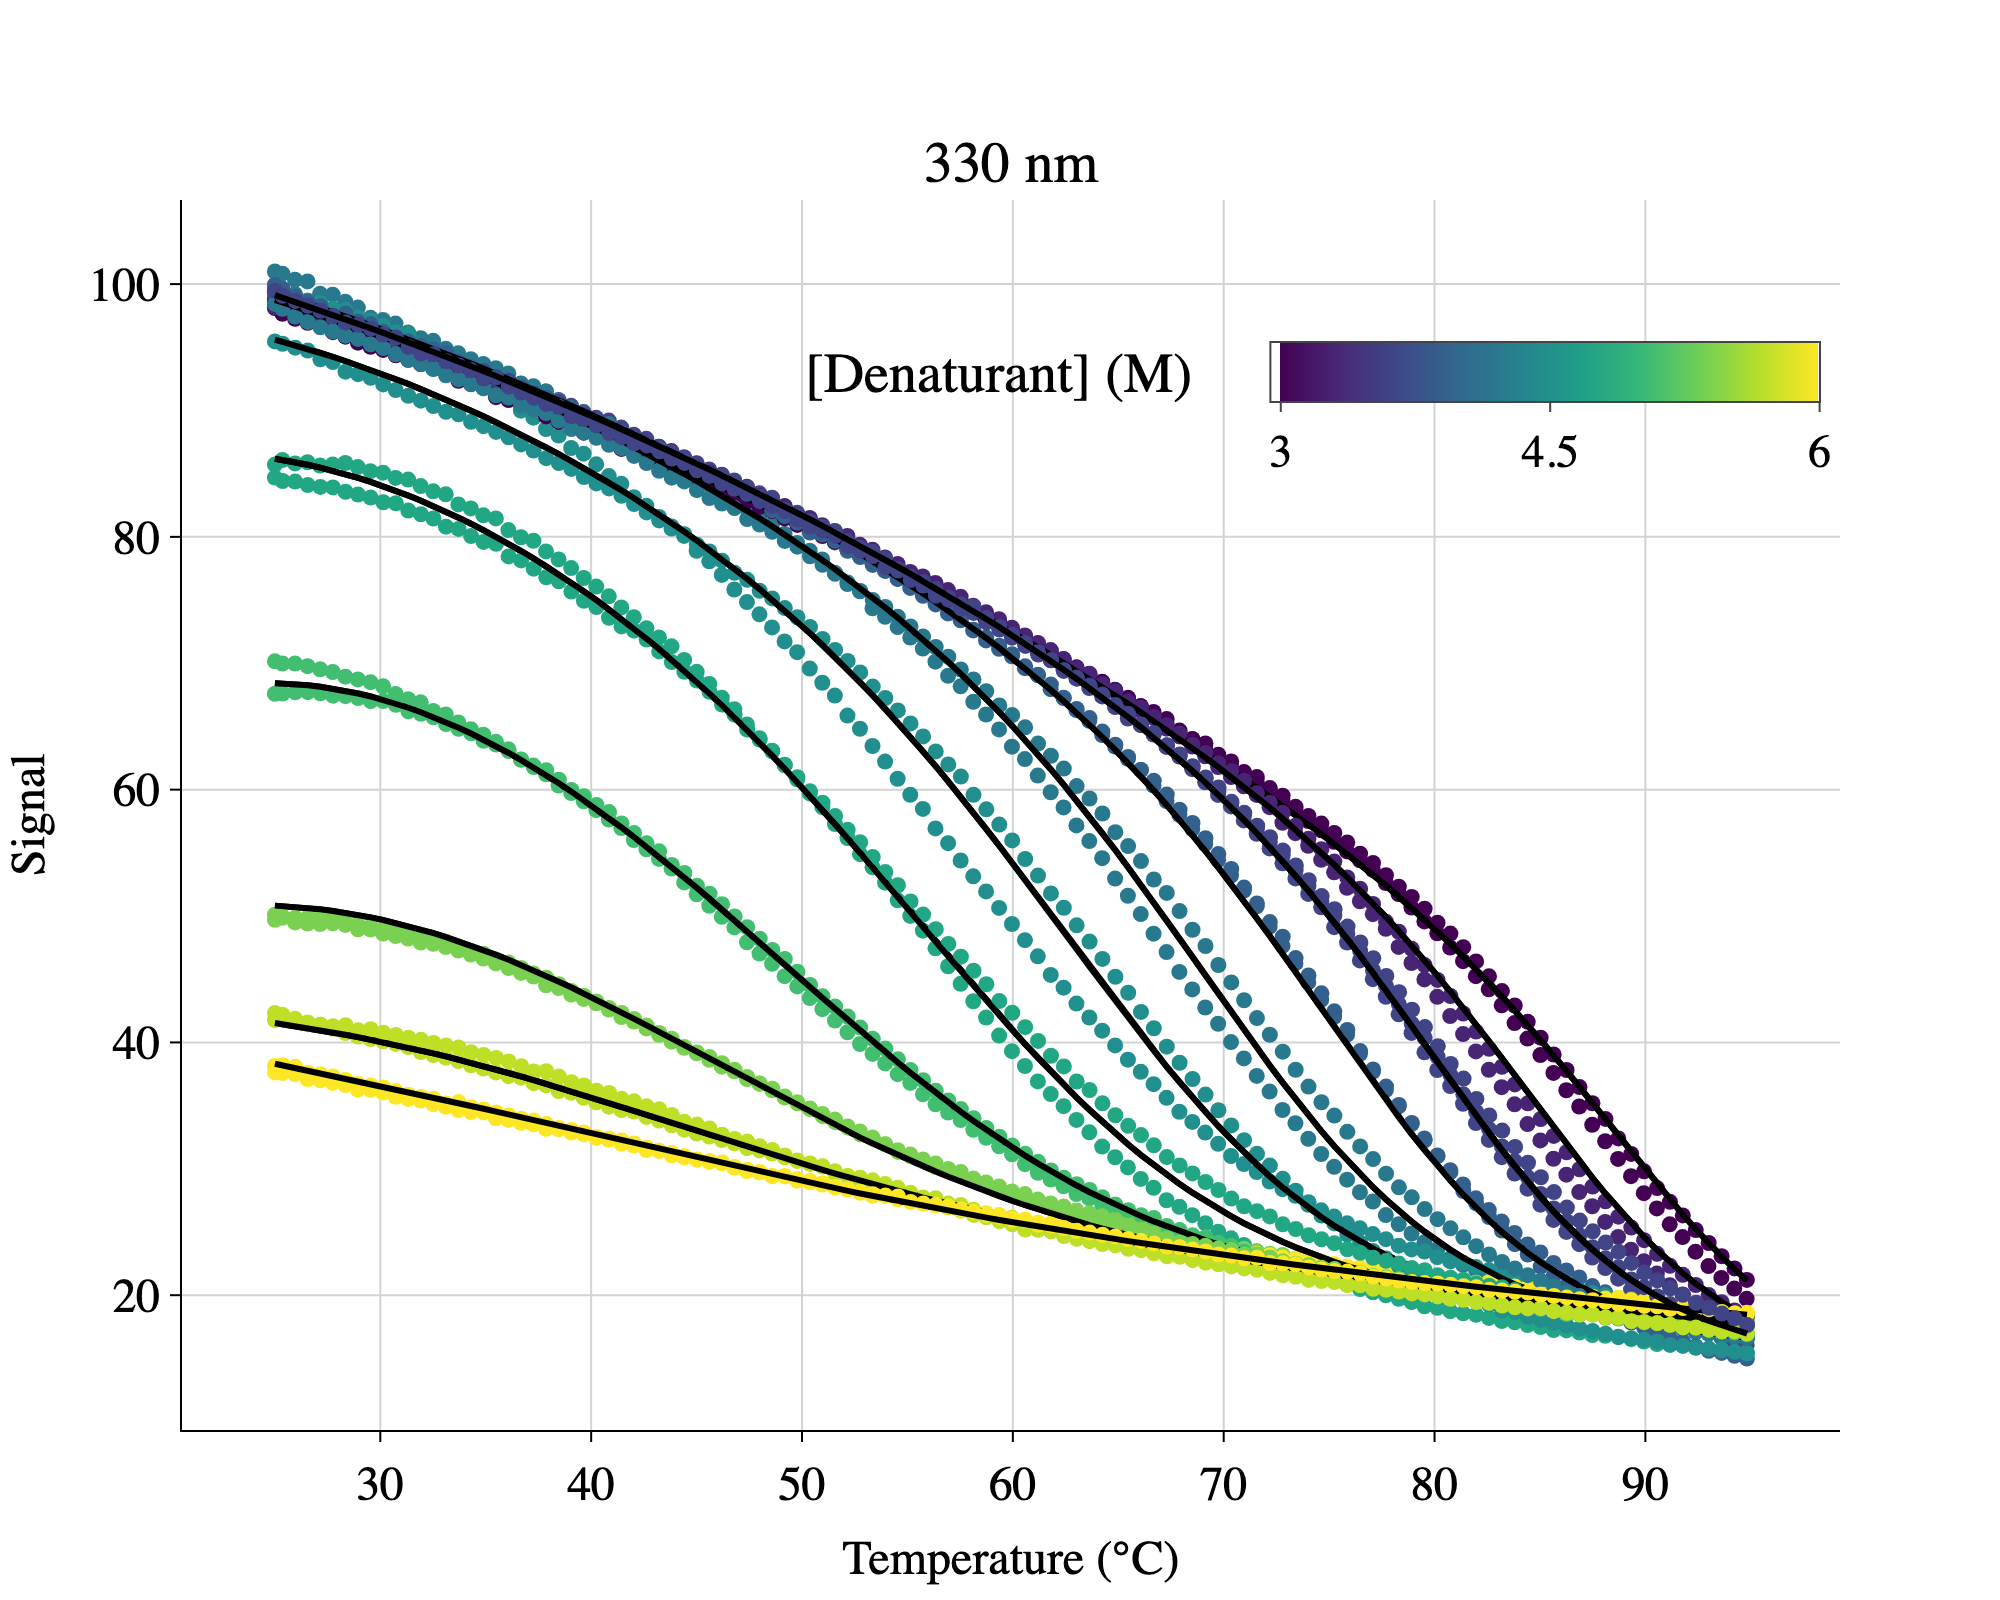

In [7]:
# Plot the curves taking into account the effect of the scaling factor
fig = plot_unfolding(best_model,plot_config=plot_config,legend_config=legend_config,use_scaled_data=True)
# save figure
#fig.write_image(f"./figures/{INDEX}_{NAME}_unfolding_curves_fitted_scaled.png")

display_figure_static(fig,height=800, width=1000)

In [8]:
"""
Save a python object as a pickle file for future plotting without need to re-fit
Required attributes are:
    - global_fit_params
    - denaturant_concentrations
    - nr_signals
    - signal_names
    - nr_den
    - temp_lst_expanded
    - predicted_lst_multiple_scaled
    - max_points
    - signal_lst_multiple_scaled
    - oligomeric
    - predicted_deriv_lst_multiple
"""

import pickle

class Test:
    pass

with open(f'./py_objects/{INDEX}_{NAME}_best_model.pkl', 'wb') as f:
    t = Test()
    t.global_fit_params = best_model.global_fit_params
    t.denaturant_concentrations = best_model.denaturant_concentrations
    t.nr_signals = best_model.nr_signals
    t.signal_names = best_model.signal_names
    t.nr_den = best_model.nr_den
    t.temp_lst_expanded = best_model.temp_lst_expanded
    t.predicted_lst_multiple_scaled = best_model.predicted_lst_multiple_scaled
    t.max_points = best_model.max_points
    t.signal_lst_multiple_scaled = best_model.signal_lst_multiple_scaled
    t.oligomeric = best_model.oligomeric
    t.predicted_deriv_lst_multiple = best_model.predicted_deriv_lst_multiple

    # dump it
    pickle.dump(t, f)